# Projektna naloga

V tej nalogi analiziram podatke o delih za dijake in študente iz študentskega servisa. Analizarala sem delovnik, trajanje, nazive, prosta mesta in naredila večji poudarek na analizi neto plače.  




In [1]:
import pandas as pd

In [2]:
df= pd.read_csv('dela.csv', index_col='id', sep=',', decimal='.')


## 1. Osnovne informacije
### 1.1 Razpredelnica s podatki del

In [3]:
df_urejen = df.sort_index() #sortiram indekse
df_urejen.head() # df.head() #Izpis prvih (privzeto) 5

,naziv,lokacija,placa_bruto,placa_neto,placa_po_dogovoru,prosta_mesta,trajanje,delovnik
id,,,,,,,,
353625,INŠTRUKCIJE,PO SLOVENIJI,9.00,7.74,False,1,DLJE ČASA (ZAČ. IN OBČ. DELO),POPOLDAN
354020,DELO V PROIZVODNJI,TRBOVLJE,8.50,7.31,False,1,DLJE ČASA (ZAČ. IN OBČ. DELO),PO DOGOVORU
355687,RAZVOZ,KRANJ,7.21,6.20,False,3,DLJE ČASA (ZAČ. IN OBČ. DELO),DOPOLDAN
356084,ELEKTROTEHNIČNA DELA,LJUBLJANA IN OKOLICA,7.21,6.20,False,2,DLJE ČASA (ZAČ. IN OBČ. DELO),DOPOLDAN
356156,STREŽBA,BRESTANICA,/,/,True,2,DLJE ČASA (ZAČ. IN OBČ. DELO),PO DOGOVORU


Tabela s podatki o id, nazivu, lokaciji, neto in bruto plači ali plači po dogovoru, prosta mesih mestih, trajanju in delovniku za posamezno delo.

In [4]:
df.shape

(4000, 8)

Tabela vsebuje 4000 vrstic in 8 stolpcev.

## 2. Analiza prvotne tabele

placa_po_dogovoru
False    3844
True      156
Name: count, dtype: int64


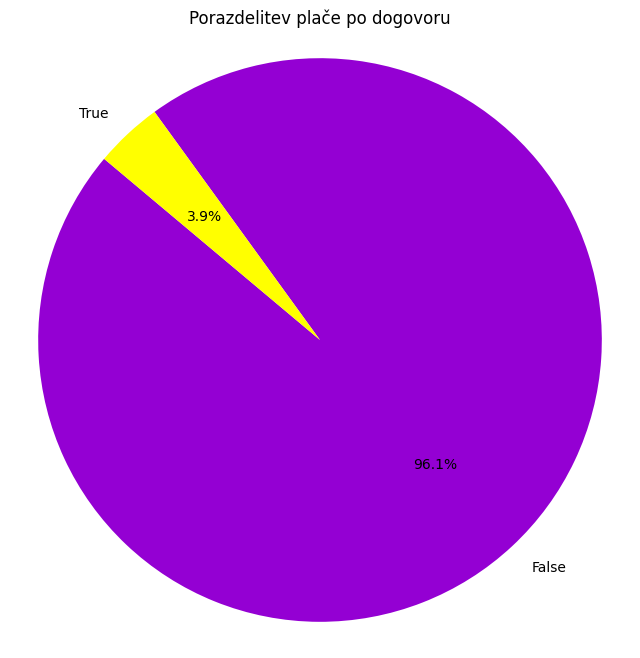

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
st_ppd = df['placa_po_dogovoru'].value_counts()
print(st_ppd)
# Ustvari tortni diagram
plt.figure(figsize=(8, 8))
plt.pie(st_ppd, labels=st_ppd.index, autopct='%1.1f%%', startangle=140, colors=['darkviolet', 'yellow'])
plt.title('Porazdelitev plače po dogovoru')
plt.axis('equal')

plt.show()


Tortni diagram, ki prikazuje procentualno razmerje med deli, kjer je plača znana in deli, kjer je plača po dogovoru. Zgoraj pa so podatki predstavljeni tudi številsko.
To se zdi precej pričakovan rezultat, saj je to ena izmed ključnih podatkov, ki zanima študente, ko si izbirajo delo, zato so radi vnaprej seznanjeni s to informacijo. Poleg tega se velikokrat zdi, da so dela po dogovoru veliko bolje plačana, zato se nekako pričakuje da bo teh precej manj.

delovnik
IZMENSKO       1480
PO DOGOVORU    1303
DOPOLDAN        846
POPOLDAN        254
MED VIKENDI     117
Name: count, dtype: int64


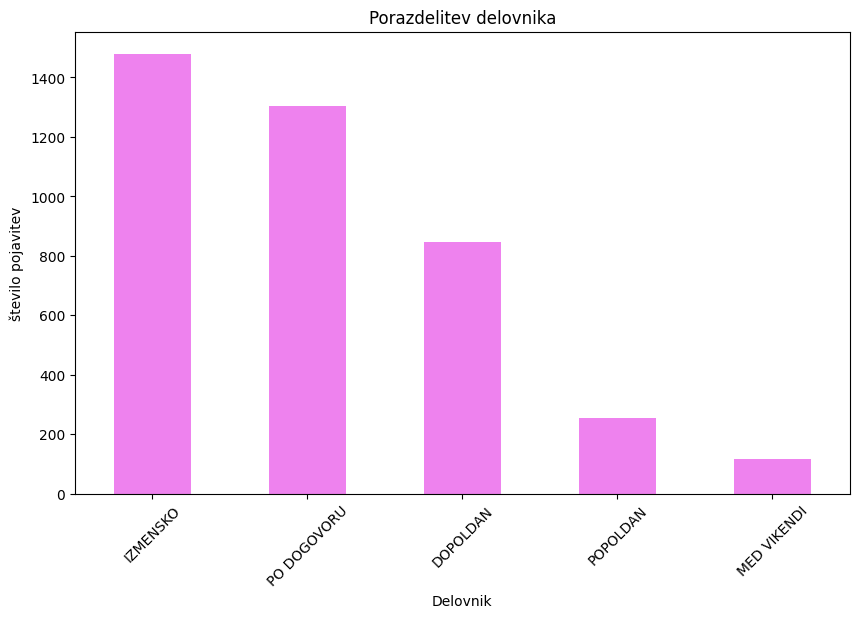

In [6]:
delovnik = df['delovnik'].value_counts() # Prešteje pojavitve
print(delovnik)

# Izriše stolpični diagram
plt.figure(figsize=(10, 6))
delovnik.plot(kind='bar', color='violet')
plt.title('Porazdelitev delovnika')
plt.xlabel('Delovnik')
plt.ylabel('število pojavitev')
plt.xticks(rotation=45)
plt.show()

Stolpični diagram predstavlja število del glede na delovnik, zgoraj pa so podatki predstavljeni tudi številsko.

Najmanj del, se odvija med vikendi, kar se zdi precej očitno  glede na to, da so vikendi po večini dela prosti dnevi, in prav tako, se zdi očitno, da je več del dopoldan kot popoldan. Vendar pa bi pričakovala več del po dogovoru. Izmenskih, predvidevam, da je več, samo zato, ker je bil tisto čas tik pred  poletno sezono.

In [7]:
df_kopija = df.copy(deep=True) # Ustvari kopijo prvotnega data frejma

Zaradi neskladnosti v poimenovanju trajanja posameznih študentskih del, sem tiste, ki se pojavijo najbolj pogosto in imajo zelo podoben zapis trajanja, vendar ne povsem enak, dala skupaj za bolj natančen pregled in analizo podatkov.

In [8]:
df_kopija.loc[df_kopija['trajanje'].str.contains('Dlje časa', case=False, na=False), 'trajanje'] = 'DLJE ČASA (ZAČ. IN OBČ. DELO)'
df_kopija.loc[df_kopija['trajanje'].str.contains('počitni', case=False, na=False), 'trajanje'] = 'POČITNIŠKO DELO'
df_kopija.loc[df_kopija['trajanje'].str.contains(r'\d', na=False, regex=True), 'trajanje'] = 'DATUMSKO DOLOČEN TERMIN'
df_kopija.loc[df_kopija['trajanje'].str.contains('po dogovoru', case=False, na=False), 'trajanje'] = 'PO DOGOVORU'
df_kopija.loc[df_kopija['trajanje'].str.contains('Polet', case=False, na=False), 'trajanje'] = 'POLETNO DELO'
df_kopija.loc[df_kopija['trajanje'].str.contains('Sezonsk', case=False, na=False), 'trajanje'] = 'SEZONSKO DELO'

trajanje
DLJE ČASA (ZAČ. IN OBČ. DELO)          2594
PO DOGOVORU                             815
POČITNIŠKO DELO                         450
DATUMSKO DOLOČEN TERMIN                 104
POLETNO DELO                             13
JULIJ                                     3
JULIJ IN AVGUST                           3
AVGUST                                    2
SEZONSKO DELO                             2
LONG PERIOD (TEMP. AND OCCAS. WORK)       1
DO OKTOBRA                                1
JUNIJ, JULIJ, AVGUST                      1
AVGUST-NOVEMBER                           1
OB PETKIH                                 1
PO POTREBI                                1
JULIJ, AVGUST                             1
VSAK PETEK POPOLDAN JULIJ IN AVGUST       1
OD JULIJA DO KONCA SEPTEMBRA              1
DO KONCA KOPALNE SEZONE                   1
DO KONCA AVGUSTA                          1
DO KONCA JULIJA                           1
JULIJ, AVGUST, SEPTEMBER                  1
PROJEKTNO DELO         

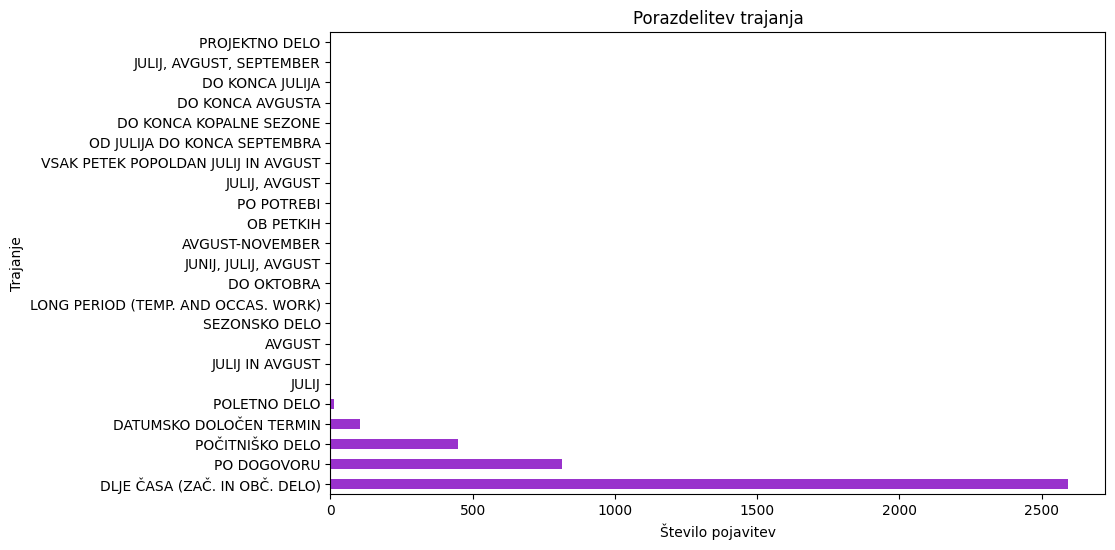

In [9]:
# Prešteje pojavitve v stolpcu trajanje
trajanje_counts = df_kopija['trajanje'].value_counts()
print(trajanje_counts)
# Izriše horizontalni diagram
plt.figure(figsize=(10, 6))
trajanje_counts.plot(kind='barh', color='darkorchid')
plt.title('Porazdelitev trajanja')
plt.xlabel('Število pojavitev')
plt.ylabel('Trajanje')
plt.show()

Horizontalni stolpični diagram predstavlja število del, glede na trajanje, zgoraj pa so podatki predstavljeni tudi številsko.

Kot pričakovano je največ del 'dlje časa(zač. in obč.)'. Poleg tega pa lahko vidimo, da je prisotno zelo veliko poletnih mesecev (junij, julij, avgust, september), kar je odraz tega, da so bili podatki pridobljeni konec junija.

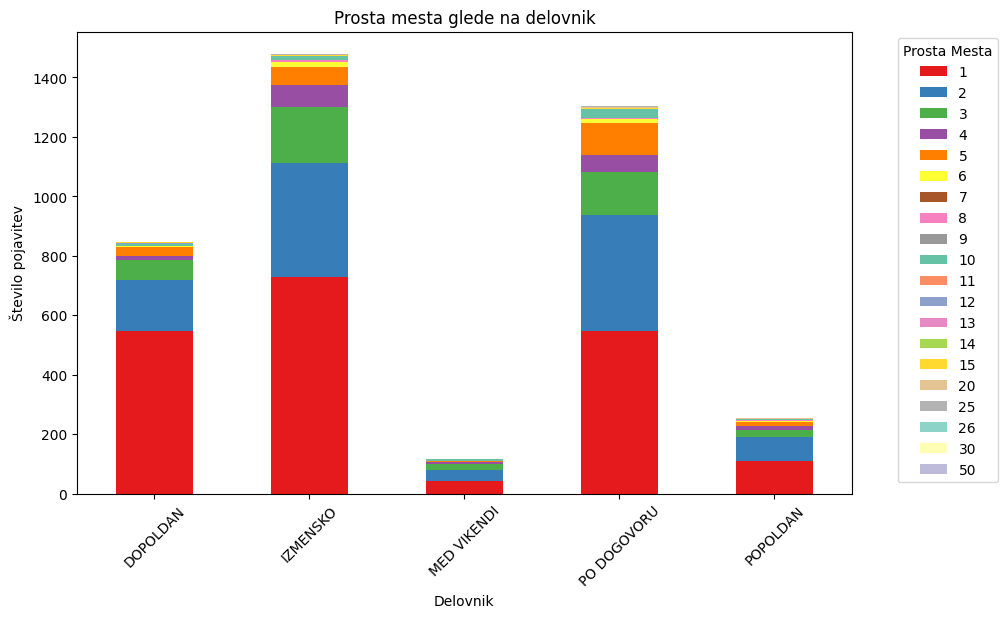

In [10]:
zdruzen = df.groupby(['delovnik', 'prosta_mesta']).size().unstack(fill_value=0)

# Ustvari barvno paleto
paleta = sns.color_palette("Set1") + sns.color_palette("Set2") + sns.color_palette("Set3")

# Izriše sestavljen stolpični grafikon
zd = zdruzen.plot(kind='bar', stacked=True, figsize=(10, 6), color=paleta)
plt.title('Prosta mesta glede na delovnik')
plt.xlabel('Delovnik')
plt.ylabel('Število pojavitev')
plt.xticks(rotation=45)

# Ustvari legendo po meri
handles, labels = zd.get_legend_handles_labels()
plt.legend(handles, labels, title='Prosta Mesta', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Stolpični diagram prikazuje prosta mesta glede na delovnik.

Pričakovano je največ del, takih kjer so največ tri prosta mesta, je pa presenetljivo tudi to, da je ponekod enako del z enim in dvema prostima mestoma.

In [11]:
naziv = df['naziv'].value_counts() # Prešteje število različnih pojavitev nazivov pred združitvijo
naziv.head(15)

,count
naziv,
STREŽBA,660
POMOČ V STREŽBI,257
STREŽBA HRANE IN PIJAČE,254
POMOČ V TRGOVINI,243
POMOČ PRI PRODAJI,218
PRODAJA,188
BLAGAJNIK,179
POMOČ V KUHINJI,124
ADMINISTRATIVNA DELA,117


Preštela sem število pojavitev posamičnih nazivov in ugotovila, da se nekatera dela zelo podobna oz. predstavljajo isto delo, zato sem jih v nadaljevanju združila, da sem dobila boljši pregled podatkov.Prav tako sem enako storila z lokacijami, čeprav na prvi pogled pri lokacijah ni zaznati tega problema, se po združitvi opazi veliko razliko v številu podatkov.

In [12]:
lokacija = df['lokacija'].value_counts() # Prešteje število različnih pojavitev lokacij pred združitvijo
lokacija.head(15)

,count
lokacija,
LJUBLJANA,792
MARIBOR,163
KOPER,108
KRANJ,104
CELJE,83
LJUBLJANA CENTER,63
LJUBLJANA,62
ŠKOFJA LOKA,57
PORTOROŽ,52


Zaradi neskladnosti v poimenovanju trajanja posameznih študentskih del, sem tiste, ki se pojavijo najbolj pogosto in imajo zelo podoben zapis lokacije in naziva, vendr ne povsem enak (primer 'Ljubljana z okolico' v 'Ljublana'), dala skupaj za bolj natančen pregled in analizo podatkov.

In [13]:
df.loc[df['lokacija'].str.contains('Ljubljana', case=False, na=False), 'lokacija'] = 'LJUBLJANA' #združim lokacije
df.loc[df['lokacija'].str.contains('Maribor', case=False, na=False), 'lokacija'] = 'MARIBOR'
df.loc[df['lokacija'].str.contains('Celje', case=False, na=False), 'lokacija'] = 'CELJE'
df.loc[df['lokacija'].str.contains('Koper', case=False, na=False), 'lokacija'] = 'KOPER'
df.loc[df['lokacija'].str.contains('Kranj', case=False, na=False), 'lokacija'] = 'KRANJ'

In [14]:
df.loc[df['naziv'].str.contains('Strežb', case=False, na=False), 'naziv'] = 'STREŽBA' # združim nazive
df.loc[df['naziv'].str.contains('Prodaj', case=False, na=False), 'naziv'] = 'PRODAJA'
df.loc[df['naziv'].str.contains('Kuh', case=False, na=False), 'naziv'] = 'POMOČ V KUHINJI'

In [15]:
naziv_st = df['naziv'].value_counts() # Prešteje število različnih pojavitev nazivov po združitvi
naziv_st.head(15)

,count
naziv,
STREŽBA,1171
PRODAJA,412
POMOČ V TRGOVINI,243
POMOČ V KUHINJI,212
BLAGAJNIK,179
ADMINISTRATIVNA DELA,117
DELO V PROIZVODNJI,109
ČIŠČENJE,73
ZDRAVSTVENA NEGA,71


In [16]:
lokacija = df['lokacija'].value_counts() # Prešteje število različnih pojavitev lokacij po združitvi
lokacija.head(15)

,count
lokacija,
LJUBLJANA,1296
MARIBOR,205
KRANJ,163
KOPER,116
CELJE,90
ŠKOFJA LOKA,57
PORTOROŽ,52
KAMNIK,49
IZOLA,48


Kot je razvidno se je 'strežba' sprva pojavila 660-krat, 'Ljubljana' pa 792-krat, po združitvi pa se je pri 'strežbi' število povečalo na 1171, pri 'Ljubljani' pa na 1296 (skoraj dvakrat več pri obeh).

## 3. Razdelitev in obdelava podatkov


Celoten df sem razdelila na dva df-ja. Prvi vsebuje podatke, kjer je 'Plača po dogovoru' enaka True, drugi pa vse ostale podatke, torej tiste pri katerih je znana plača.


In [17]:
df_ppd_true = df[df['placa_po_dogovoru'] == True] #razdelim na dva df
df_ppd_false = df[df['placa_po_dogovoru'] == False]

In [18]:
df_ppd_false.head(3)

,naziv,lokacija,placa_bruto,placa_neto,placa_po_dogovoru,prosta_mesta,trajanje,delovnik
id,,,,,,,,
432434,STREŽBA,BREZOVICA PRI LJUBLJANI,9.30,8.00,False,1,DLJE ČASA (ZAČ. IN OBČ. DELO),PO DOGOVORU
432433,VZDRŽEVANJE,SLADKI VRH,9.00,7.74,False,1,PO DOGOVORU,PO DOGOVORU
432431,PROMOCIJA,POSTOJNA,7.55,6.50,False,2,AVGUST,POPOLDAN


In [19]:
df_ppd_true.head(3)

,naziv,lokacija,placa_bruto,placa_neto,placa_po_dogovoru,prosta_mesta,trajanje,delovnik
id,,,,,,,,
432380,ADMINISTRATIVNA DELA,LJUBLJANA,/,/,True,2,DLJE ČASA (ZAČ. IN OBČ. DELO),IZMENSKO
432264,VARSTVO,"ANKARAN, DEBELI RTIČ",/,/,True,3,MED POLETJEM,PO DOGOVORU
432380,ADMINISTRATIVNA DELA,LJUBLJANA,/,/,True,2,DLJE ČASA (ZAČ. IN OBČ. DELO),IZMENSKO


### 3.1. Analiza podatkov v ppd_false

In [20]:
df_ppd_false = df_ppd_false.drop(columns=['placa_po_dogovoru']) # odstranim stolpec placa_po_dogovoru
df_ppd_false.head(10)

,naziv,lokacija,placa_bruto,placa_neto,prosta_mesta,trajanje,delovnik
id,,,,,,,
432434,STREŽBA,BREZOVICA PRI LJUBLJANI,9.30,8.00,1,DLJE ČASA (ZAČ. IN OBČ. DELO),PO DOGOVORU
432433,VZDRŽEVANJE,SLADKI VRH,9.00,7.74,1,PO DOGOVORU,PO DOGOVORU
432431,PROMOCIJA,POSTOJNA,7.55,6.50,2,AVGUST,POPOLDAN
432430,PROJEKTNO DELO,LJUBLJANA,8.30,7.14,1,DLJE ČASA (ZAČ. IN OBČ. DELO),DOPOLDAN
432428,DELO V PROIZVODNJI,SLOVENSKA BISTRICA,7.21,6.20,1,JULIJ,DOPOLDAN
432426,ADMINISTRATIVNA DELA,BRNIK,7.50,6.45,1,PO DOGOVORU,DOPOLDAN
432425,KONTROLA KAKOVOSTI,SLADKI VRH,7.50,6.45,1,PO DOGOVORU,IZMENSKO
432424,VRTNARSKA DELA,BLED,9.74,8.38,2,PO DOGOVORU,DOPOLDAN
432423,STREŽBA,GORNJA RADGONA,8.72,7.50,2,DLJE ČASA (ZAČ. IN OBČ. DELO),POPOLDAN


In [21]:
# pretvori placa_neto in placa_bruto v numerično spremenljivko, neštevilske nize pa pretvori v NaN
df_ppd_false['placa_neto'] = pd.to_numeric(df_ppd_false['placa_neto'], errors='coerce')
df_ppd_false['placa_bruto'] = pd.to_numeric(df_ppd_false['placa_bruto'], errors='coerce')

# dostrani vrstice z NaN vrednostjo pri placa_neto ali placa_bruto
df_ppd_false = df_ppd_false.dropna(subset=['placa_neto', 'placa_bruto'])

    lokacija  prosta_mesta
0      CELJE            90
1      KOPER           116
2      KRANJ           163
3  LJUBLJANA          1296
4    MARIBOR           205


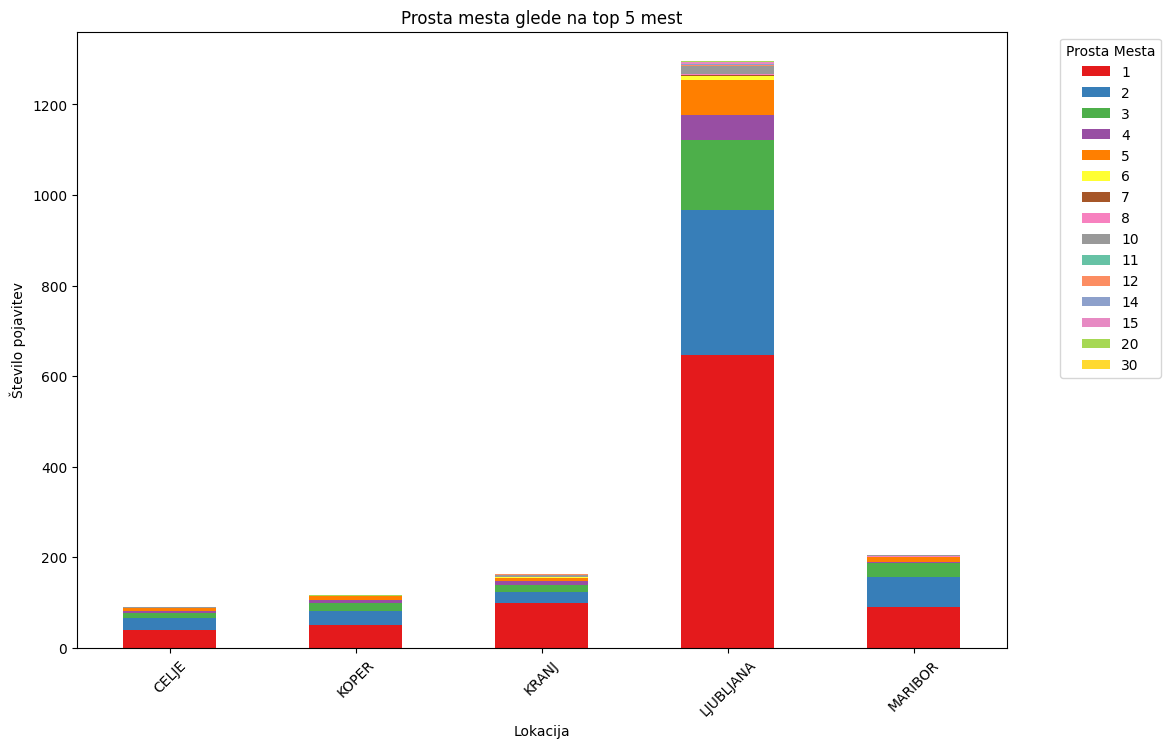

In [22]:
top_5_mest = df['lokacija'].value_counts().head(5).index

# Ustvari barvno paleto
paleta = sns.color_palette("Set1") + sns.color_palette("Set2") + sns.color_palette("Set3")

# poišče lokacije, kjer je 'lokacija' v top 5 mestih
df_top_mesta = df[df['lokacija'].isin(top_5_mest)]
prosta_mesta = df_top_mesta.groupby('lokacija')['prosta_mesta'].count().reset_index()
print(prosta_mesta)
# Združi po 'lokacija' in 'prosta_mesta'in prešteje pojavitve
grouped = df_top_mesta.groupby(['lokacija', 'prosta_mesta']).size().unstack()

# Ustvari sestavljen stolpični diagram
grouped.plot(kind='bar', stacked=True, figsize=(12, 8), color = paleta)
plt.title('Prosta mesta glede na top 5 mest')
plt.xlabel('Lokacija')
plt.ylabel('Število pojavitev')
plt.xticks(rotation=45)
plt.legend(title='Prosta Mesta', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Graf predstavlja, koliko je možnih prostih mest na določeno delo, glede na to v kateri lokaciji se nahaja to delo.

Očitno se zdi, da je največ takih del, ki imajo možnost zaposlitve le ene ali dveh oseb. Poleg tega pa nam ta graf prikazuje tudi, v katerem mestu je največ prostih mest, zgoraj pa so tudi točni numerični podatki. Ker je Ljubljana prestolnica, se ne zdi presenetljivo, da je tu največ prostih mest, bi pa mogoče pričakovala, da bi imel Koper, ki je obmorsko in zelo turistično mesto sploh v času poletne sezone več prostih mest.

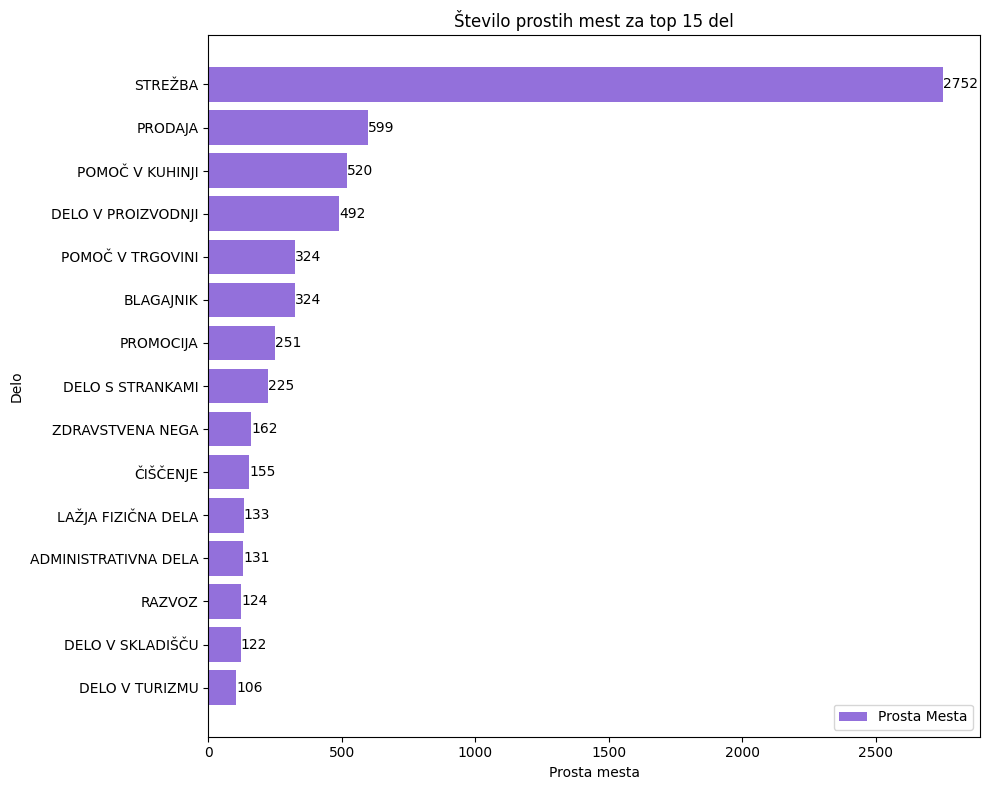

In [23]:
zdruzeni = df.groupby('naziv')['prosta_mesta'].sum().reset_index() # razvrsti nazive po prostih mestih

# Uredi top 15 del padajoče glede na prosta mesta
top_15_del = zdruzeni.sort_values(by='prosta_mesta', ascending=False).head(15)

# Izriše horizontalni diagram
plt.figure(figsize=(10, 8))
bars = plt.barh(top_15_del['naziv'], top_15_del['prosta_mesta'], color='mediumpurple')

# Prikaz števila prostih mest poleg stolpcev
for bar in bars:
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, int(bar.get_width()),
             va='center', ha='left', fontsize=10, color='black')

# Prikaz legende
plt.legend(['Prosta Mesta'], loc='lower right')

plt.title('Število prostih mest za top 15 del')
plt.xlabel('Prosta mesta')
plt.ylabel('Delo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Graf prikazuje število prostih mest glede na 15 najbolj pogosto ponujenih del.

Specifično v času poletne sezone in tudi nasploh se zdi očitno da je najbolj iskano delo z največ prostimi mesti strežba v raznoraznih lokalih in restavracijah, prav tako pa tudi vsa ostala dela, ki se navezujejo na delo v restavracijah, torej pomoč v kuhinji. Razumno je tudi, da so najpogostejša dela, lažja fizična dela, ki ne zahtevajo veliko predznanja, sem spada tudi delo v proizvodnji in skladišču, ter raznorazno delo v trgovinah, čiščenje, razvoz ipd. Najbolj opazno pa se je v zadnjem času povečalo povpraševanje za promocijsko delo, kar je tudi razvidno iz grafa.   

In [24]:
df_ppd_false['placa_neto'] = pd.to_numeric(df_ppd_false['placa_neto'], errors='coerce')
df_ppd_false['placa_bruto'] = pd.to_numeric(df_ppd_false['placa_bruto'], errors='coerce')

# odstrani vrstice z NaN vrednostjo pri placa_neto ali placa_bruto
df_ppd_false = df_ppd_false.dropna(subset=['placa_neto', 'placa_bruto'])

# Prešteje število ponujenih del, glede na mesta
st_del = df_ppd_false['lokacija'].value_counts()

# razbere top 5 mest za največ ponujenimi službami
top_5_mest = st_del.head(5).index

# pregleda df in ohrani le tista v top 5
df_top_5_mest = df_ppd_false[df_ppd_false['lokacija'].isin(top_5_mest)]

# izračun povprečne neto plače za top 5 mest
povprecna_placa_neto_top_5_mest = df_top_5_mest.groupby('lokacija')['placa_neto'].mean()
povprecna_placa_neto_top_5_mest = povprecna_placa_neto_top_5_mest.round(2)
povprecna_placa_neto_top_5_mest = povprecna_placa_neto_top_5_mest.sort_values(ascending=False)


print(povprecna_placa_neto_top_5_mest)



lokacija
KRANJ        7.74
LJUBLJANA    7.64
KOPER        7.49
CELJE        7.39
MARIBOR      7.29
Name: placa_neto, dtype: float64


Izpis prikazuje povprečno plačo za prvih 5 lokacij, kjer je največ povpraševanja po delovni sili, spodaj pa je ta tabela prikazana tudi s točkastim grafom, ter z izhodiščem, ki se ne začne v 0, saj so na ta način razlike bolj opazne.

Ker je največ del v Ljubljani, bi zato mogoče celo lahko pričakovali tam najmanjšo povprečno plačo, saj bi bilo lahko veliko del, ki so plačana minimalno, vendar se očitno pozna to, da je v Ljubljani višji standard, torej so tudi plače temu primerne, sploh če primerjamo z Mariborom, ki je prav tako veliko mesto, vendar je standard življenja nekoliko ugodnejši. Najbolj presenetljivo je, da so si neto plače med seboj zelo blizu, torej ni velike razlike med posameznimi kraji, vendar pa moramo vedeti, da govorimo o povprečni plači.

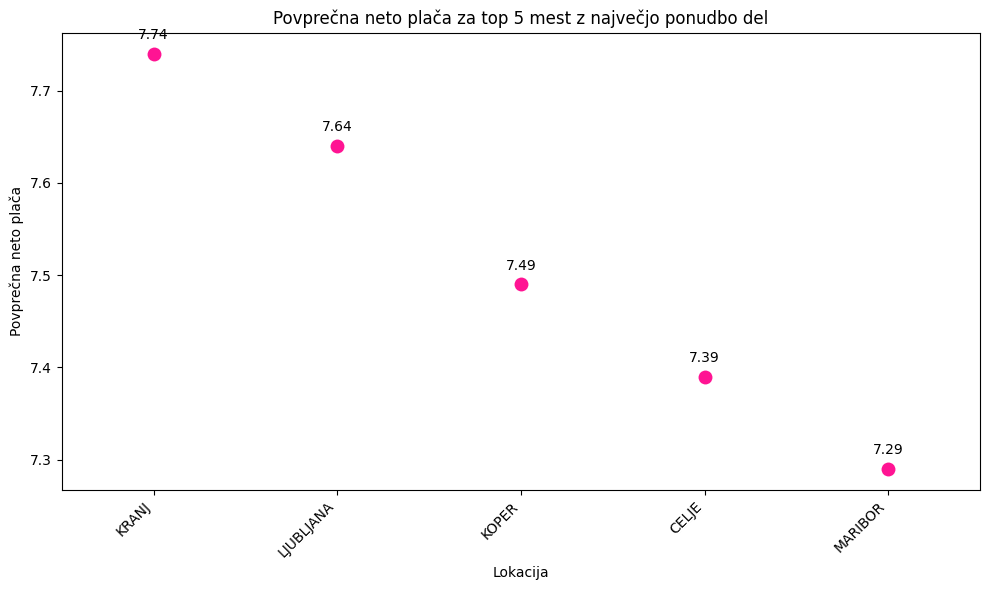

In [25]:
povprecna_placa_neto_top_5_mest_df = povprecna_placa_neto_top_5_mest.reset_index()

# Ustvari točkast grafikon
plt.figure(figsize=(10, 6))
sns.stripplot(x='lokacija', y='placa_neto', data=povprecna_placa_neto_top_5_mest_df, size=10, color='deeppink')

# Doda oznake
for indeks, vrsta in povprecna_placa_neto_top_5_mest_df.iterrows():
    plt.text(indeks, vrsta['placa_neto'] + 0.02, f"{vrsta['placa_neto']:.2f}", va='center', ha='center', fontsize=10, color='black')

plt.title('Povprečna neto plača za top 5 mest z največjo ponudbo del')
plt.xlabel('Lokacija')
plt.ylabel('Povprečna neto plača')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [26]:
# prešteje število del glede na naziv
st_del = df_ppd_false['naziv'].value_counts()

# razbere top 15 del za največ ponujenimi službami
top_15_del = st_del.head(15).index

# pregleda df in ohrani le tista v top 15
df_top_15_del = df_ppd_false[df_ppd_false['naziv'].isin(top_15_del)]

# izračun povprečne neto plače za top 15 del
povprecna_placa_neto_top_15_del = df_top_15_del.groupby('naziv')['placa_neto'].mean()
povprecna_placa_neto_top_15_del = povprecna_placa_neto_top_15_del.round(2)

# uredi povprečja padajoče
povprecna_placa_neto_top_15_del = povprecna_placa_neto_top_15_del.sort_values(ascending=False)

print(povprecna_placa_neto_top_15_del)

naziv
PROMOCIJA                     8.66
DELO S STRANKAMI              8.11
ČIŠČENJE                      7.79
ZDRAVSTVENA NEGA              7.78
STREŽBA                       7.64
POMOČ V KUHINJI               7.61
BLAGAJNIK                     7.59
DELO NA RECEPCIJI             7.37
DELO NA BENCINSKEM SERVISU    7.36
RAZVOZ                        7.17
DELO V SKLADIŠČU              7.15
ADMINISTRATIVNA DELA          7.12
PRODAJA                       7.04
DELO V PROIZVODNJI            6.92
POMOČ V TRGOVINI              6.89
Name: placa_neto, dtype: float64


Zgoraj je prikazana tabela za povprečno neto plačo, pri 15 najbolj iskanih delih. Spodaj pa je na podlagi tabele narisan stolpični horizontalni graf.

Pričakovala sem, da bojo čiščenje, zdravtsvena nega in promocija nekje na vrhu. Čiščenje zato, ker je ponavadi zelo dobro plačano če upoštevamo dejstvo, da iščejo le nekoga za uro ali dve dela, promocija zahteva veliko ustvarjalnosti in inovativnosti in skoraj konstantno 'brain stormanje' idej, zdravstvena nega, je pa že od nekdaj zelo povpraševano delo, ker zahteva celega človeka in temu primerno plačilo.
Ni me pa tudi presenetilo da je delo v prodaji najslabše plačano izmed vseh najbolj povpraševanih del. Se pa sicer povprečno delo, ki je najbolj plačano od tistega, ki je najmanj, razlikuje za približno 1.80€ na uro, kar pri osem urnem delovniku privede do približno 14€ na dan razlike, kar se na dolgi rok že precej pozna.


<ipython-input-27-03bca16b0385>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='placa_neto', y='naziv', data=povprecna_placa_neto_top_15_del_df, palette='viridis')


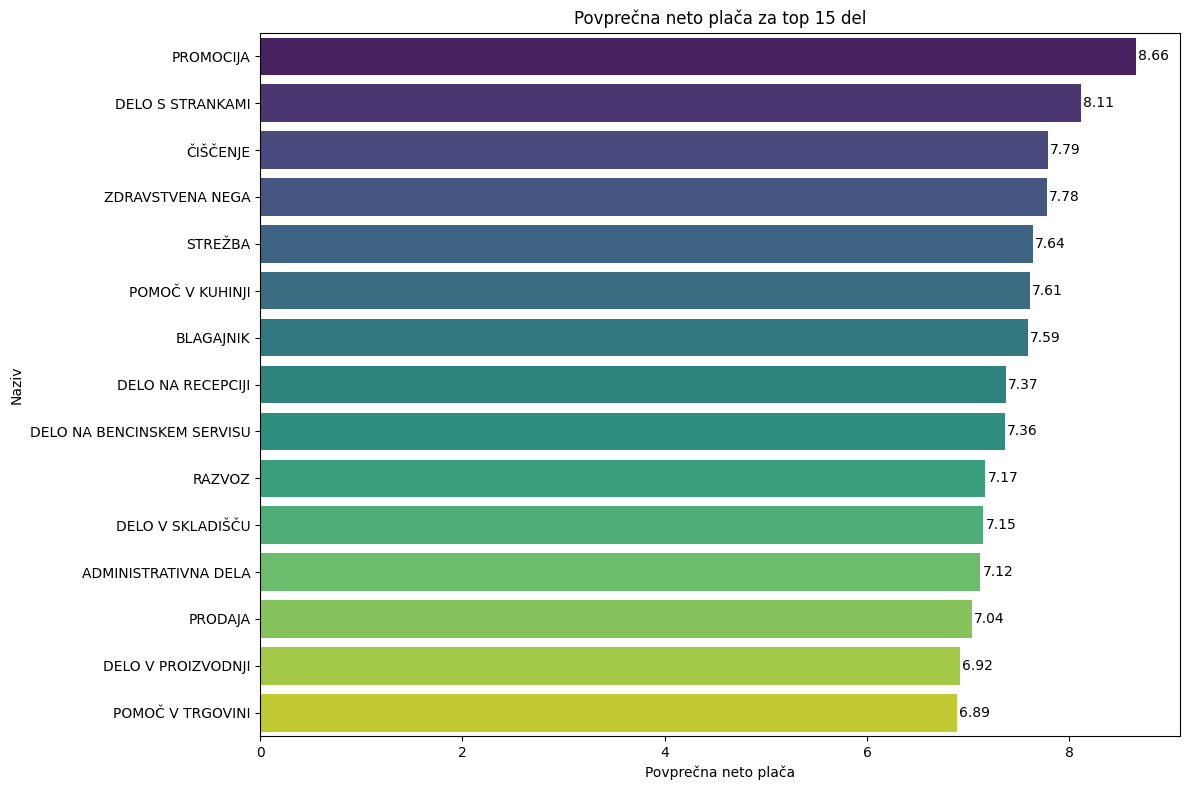

In [27]:
povprecna_placa_neto_top_15_del_df = povprecna_placa_neto_top_15_del.reset_index()

# ustvari horizontalni diagram
plt.figure(figsize=(12, 8))
sns.barplot(x='placa_neto', y='naziv', data=povprecna_placa_neto_top_15_del_df, palette='viridis')

# Doda oznake
for indeks, vrsta in povprecna_placa_neto_top_15_del_df.iterrows():
    plt.text(vrsta['placa_neto'] + 0.02, indeks, f"{vrsta['placa_neto']:.2f}", va='center', ha='left', fontsize=10, color='black')

plt.title('Povprečna neto plača za top 15 del')
plt.xlabel('Povprečna neto plača')
plt.ylabel('Naziv')
plt.tight_layout()
plt.show()

In [28]:
# izračun povprečne neto plače za vsa dela
povprecna_placa_neto_vsa_dela = df_ppd_false.groupby('naziv')['placa_neto'].mean()
povprecna_placa_neto_vsa_dela = povprecna_placa_neto_vsa_dela.round(2)
# uredi povprečja padajoče
povprecna_placa_neto_vsa_dela = povprecna_placa_neto_vsa_dela.sort_values(ascending=False)

# Identify the top 5 jobs with the highest average 'placa_neto'
top_15_placanih_del = povprecna_placa_neto_vsa_dela.head(15)

# Print the sorted averages for top 5 jobs
print(top_15_placanih_del)

naziv
PREVAJANJE              15.37
TRENER/KA               12.54
UČITELJ/ICA PLAVANJA    11.83
SVETOVALEC/KA           11.73
VADITELJ/ICA            11.27
POUČEVANJE              11.26
MODEL                   11.00
KINEZIOLOG/INJA         10.15
PREDAVANJE              10.00
REŠEVALEC/KA IZ VODE     9.91
PROGRAMIRANJE            9.88
DELO V FITNESU           9.56
MEDICINSKA SESTRA        9.10
TRŽENJE                  9.04
PROMOCIJA                8.66
Name: placa_neto, dtype: float64


Zgoraj je prikazana tabela za povprečno neto plačo, pri 15 najbolje plačanih delih. Spodaj pa je na podlagi tabele narisan stolpični horizontalni graf.

Najbolj me je presenetilo programiranje, za katerega bi pričakovala, da bo med top 5 najbolje plačanih, vendar imam v spominu, da je veliko takih del plačanih po dogovoru, kar bi verejetno temu, še zvišalo povprečje, če bi delodajalci navedli točne postavke. Me pa pozitivno preseneča, da so dela, ki zahtevajo športno obremenitev, torej vsi učitelji športnih dejavnosti skupaj z reševalci iz vode in trenerji v fitnesu, med najbolje plačanimi, saj je to zelo fizično in psihično izčrpajoče delo. Sem pa se takoj ob pogledu na rezultate spomnila tudi, kako dobro plačano je prevajanje, saj sem ob iskanju dela zase včasih zasledila tudi postavke v višino 20€ neto. Če pa spet izračunamo približno razliko med povprečno najbolje plačanim delom (prevajanje) in 15. povprečno najbolje plačanim delom, je razlika precejšnja in sicer 6.70€ na uro, kar za 8 urni delovnik pomeni 53.60€ na dan, kar je za skoraj cel dan dodatnega plačila.  

<ipython-input-29-c7d641468f5a>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='placa_neto', y='naziv', data=top_15_placanih_del_df, palette='viridis')


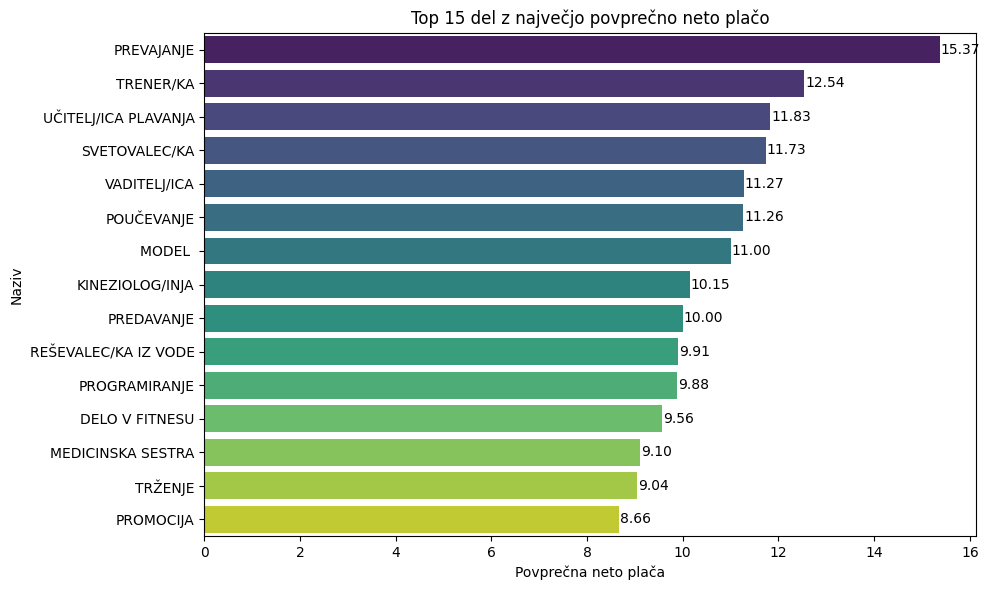

In [29]:
top_15_placanih_del_df = top_15_placanih_del.reset_index()

# Ustvari horizontalni diagram
plt.figure(figsize=(10, 6))
sns.barplot(x='placa_neto', y='naziv', data=top_15_placanih_del_df, palette='viridis')

# Doda oznake
for indeks, vrsta in top_15_placanih_del_df.iterrows():
    plt.text(vrsta['placa_neto'] + 0.02, indeks, f"{vrsta['placa_neto']:.2f}", va='center', ha='left', fontsize=10, color='black')

plt.title('Top 15 del z največjo povprečno neto plačo')
plt.xlabel('Povprečna neto plača')
plt.ylabel('Naziv')
plt.tight_layout()
plt.show()

naziv
ETIKETIRANJE                          6.20
FOTOGRAFIRANJE                        6.20
INVENTURA                             6.20
PARKIRANJE VOZIL                      6.20
POLNJENJE POLIC                       6.28
POMOČNIK VZGOJITELJA/VZGOJITELJICE    6.30
RAČUNALNIŠKE STORITVE                 6.40
DELO V LOTERIJI                       6.50
DELO V TISKARNI                       6.51
MIZARSKA DELA                         6.57
DEKLARIRANJE                          6.58
DELO V LABORATORIJU                   6.62
INFORMATOR/KA                         6.72
TELEFONSKI MARKETING                  6.73
DELO V LOGISTIKI                      6.78
Name: placa_neto, dtype: float64


<ipython-input-30-56eff6650154>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='placa_neto', y='naziv', data=najslabse_placanih_15_df, palette='coolwarm')


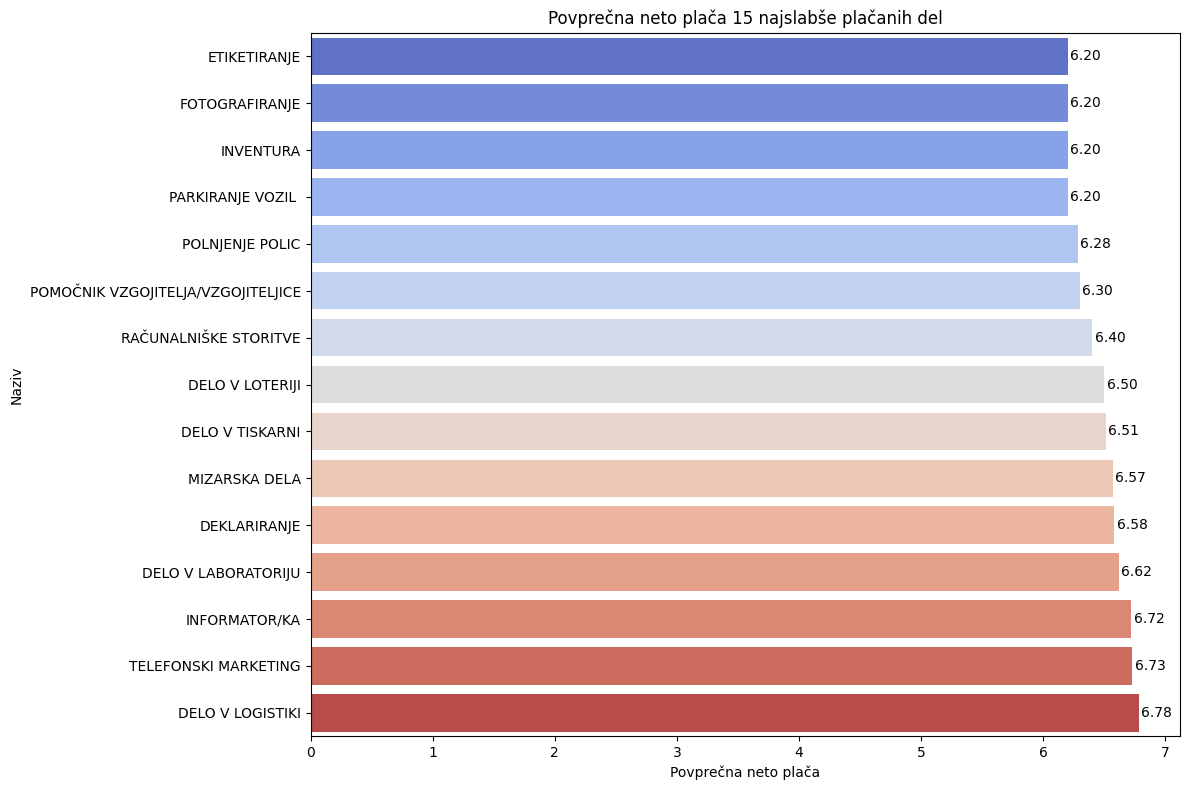

In [30]:

df_ppd_false['placa_neto'] = pd.to_numeric(df_ppd_false['placa_neto'], errors='coerce')


povprecna_neto_placa_za_delo = df_ppd_false.groupby('naziv')['placa_neto'].mean()

# določi 10 najslabše plačanih del, glede na povprečno neto plačo
najslabse_placanih_15 = povprecna_neto_placa_za_delo.nsmallest(15).round(2)

print(najslabse_placanih_15)
# Reset index for plotting
najslabse_placanih_15_df = najslabse_placanih_15.reset_index()

# Create a horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x='placa_neto', y='naziv', data=najslabse_placanih_15_df, palette='coolwarm')

# Add data labels
for index, row in najslabse_placanih_15_df.iterrows():
    plt.text(row['placa_neto'] + 0.02, index, f"{row['placa_neto']:.2f}", va='center', ha='left', fontsize=10, color='black')

plt.title('Povprečna neto plača 15 najslabše plačanih del')
plt.xlabel('Povprečna neto plača')
plt.ylabel('Naziv')
plt.tight_layout()
plt.show()


Zgoraj je prikazan horizontalni stolpični graf, ki prikazuje 15 najslabše plačanih del, glede na povprečno plačo.

Najslabše plačana dela s povprečno plačo 6.20€ oz. minimalno postavko so kar 4 in sicer meni najbolj izstopa fotografiranje, čeprav se ne zdi ravno zahtevno delo samo po sebi pa vseeno zahteva precizno oko, ki ima pozornost za detajle in estetiko, torej da zna ljudi ali predmete prikazati na očesu privlačen način, saj kot tudi vemo so raznorazna fotografiranja porok, birem, krstov ipd. precej draga. Višjo plačo bi si zaslužili tudi pomočniki vzgojiteljev v vrtcu, saj je delo zelo naporno in ne diši ravno vsem, poleg tega pa zahteva osebo, ki ima rada otroke, vendar pa nižja postavka verjetno privabi ravno take ljudi, ki to res radi delajo in so dobri v tem in to delajo bolj iz lastne želje kot iz zaslužka. Še najbolj pa me je presenetilo, da so se tukaj znašla tudi mizarska dela, saj se mi zdi, da so mizarji večinoma zelo dobro plačani in spoštovani, saj je delo zelo precizino in morda tudi malce nevarno in pa laboratorijsko delo, ki ponavadi zahteva strokovnjake na področju iz kemije/farmacije/fizike ponavadi študente višjih letnikov, ki bi si zaradi svoje usposobljenosti zaslužili višjo postavko.  

<ipython-input-31-fae2ed7e40a4>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='povprečna_neto_placa', y='naziv', data=top_15_del_df, palette='viridis')


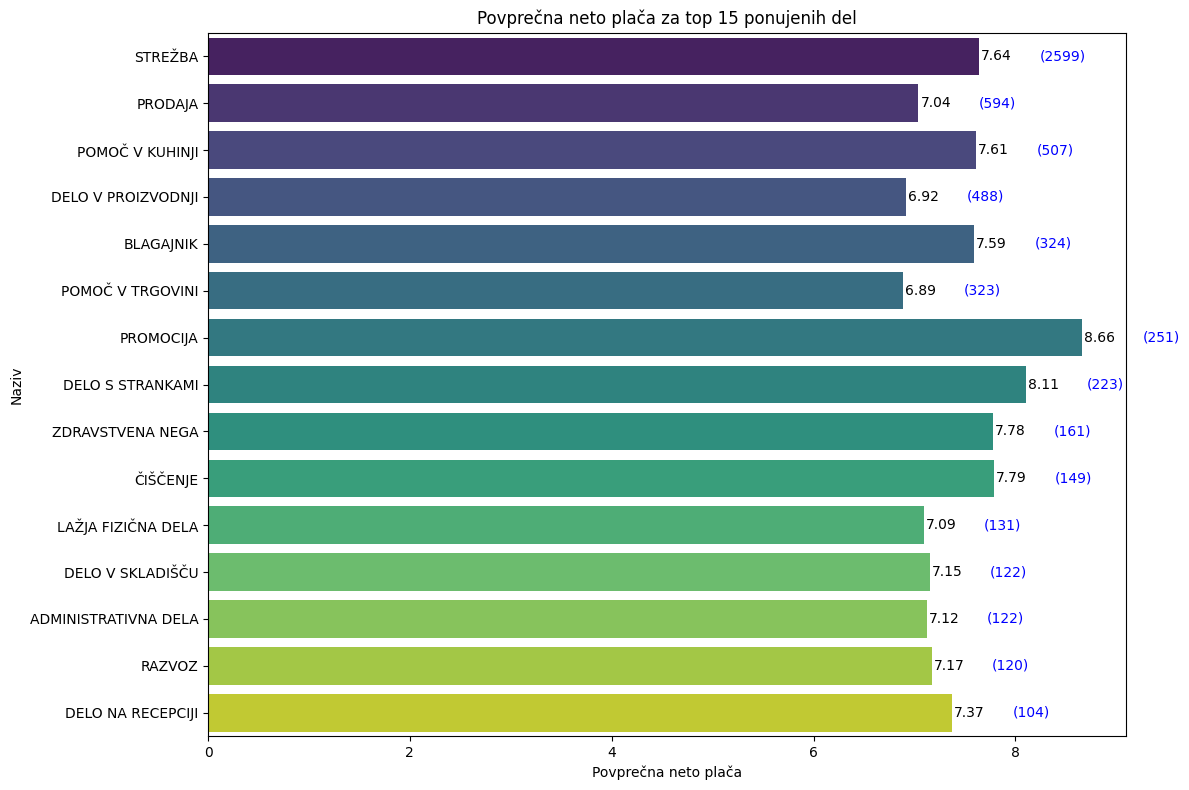

In [31]:
povprecna_neto_placa_za_naziv = df_ppd_false.groupby('naziv')['placa_neto'].mean().round(2)

# preštej vsa prosta_mesta za posamično službo
prosta_mesta = df_ppd_false.groupby('naziv')['prosta_mesta'].sum()

# Združi povprečja in pojavitve v en df
st_del = pd.DataFrame({
    'povprečna_neto_placa': povprecna_neto_placa_za_naziv,
    'vsa_prosta_mesta': prosta_mesta
})

# Uredi glede na število ponujenih del
st_del = st_del.sort_values(by='vsa_prosta_mesta', ascending=False)

top_15_del = st_del.head(15)

top_15_del_df = top_15_del.reset_index()

# Ustvari horizontalni diagram
plt.figure(figsize=(12, 8))
sns.barplot(x='povprečna_neto_placa', y='naziv', data=top_15_del_df, palette='viridis')

# Doda oznake
for indeks, vrsta in top_15_del_df.iterrows():
    plt.text(vrsta['povprečna_neto_placa'] + 0.02, indeks, f"{vrsta['povprečna_neto_placa']:.2f}", va='center', ha='left', fontsize=10, color='black')
    plt.text(vrsta['povprečna_neto_placa'] + 0.6, indeks, f"({int(vrsta['vsa_prosta_mesta'])})", va='center', ha='left', fontsize=10, color='blue')

plt.title('Povprečna neto plača za top 15 ponujenih del')
plt.xlabel('Povprečna neto plača')
plt.ylabel('Naziv')
plt.tight_layout()
plt.show()

Zgoraj je narisan stolpični horizontalni graf, ki prikazuje povprečno neto plačo za top 15 ponujenih del, skupaj z vsemi možnimi prostimi mesti, napisanimi poleg stolpcev v oklepajih.

Iz grafa je vidno, da število prostih mest ne vpliva na višino povprečne neto plače, čeprav sem morda pričakovala, da manj kot je mest višja bo povprečna plača, saj bi bile bolj enotne postvake in manjša razlika pri izračunanem povprečju. Vendar pa vidimo, da sta ti spremenljivki med seboj popolnoma neodvisni  

<ipython-input-32-e4e8d169207b>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='delovnik', y='placa_neto', data=povprecna_placa_neto_za_delovnik_df, palette='viridis')


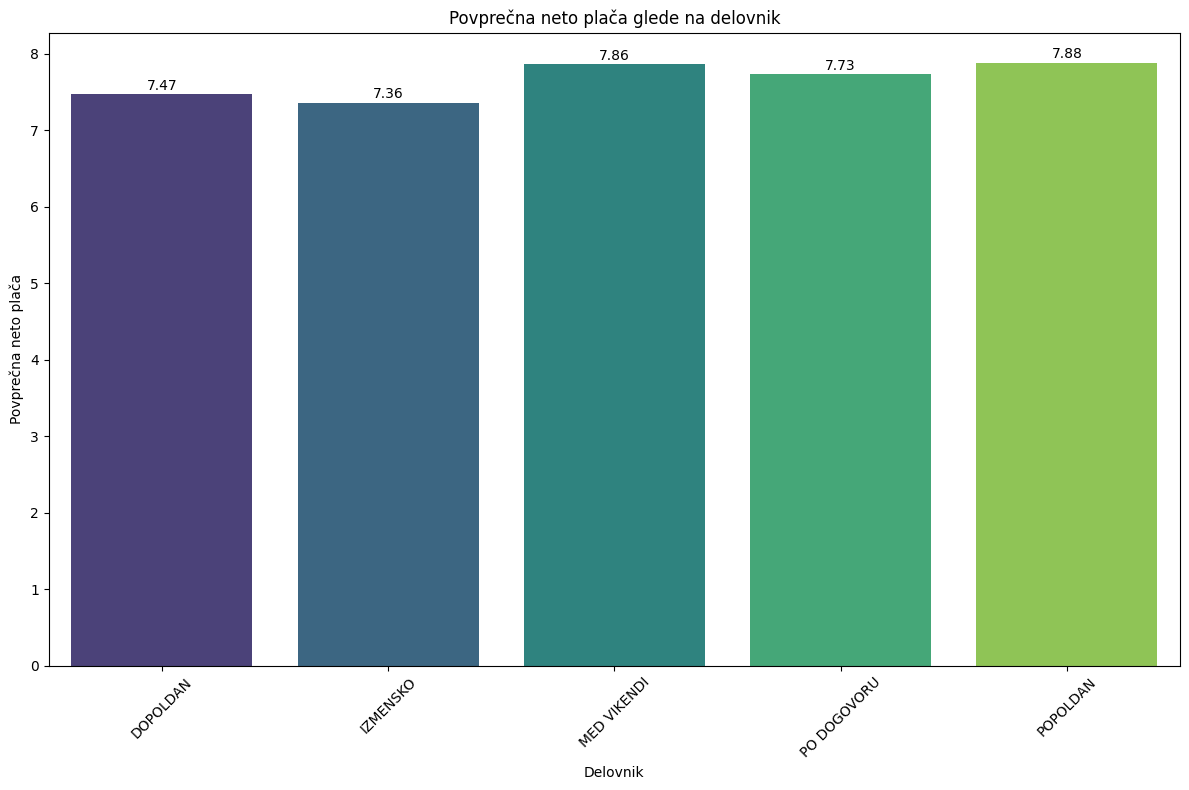

In [32]:
povprecna_placa_neto_za_delovnik = df_ppd_false.groupby('delovnik')['placa_neto'].mean().round(2)

povprecna_placa_neto_za_delovnik_df = povprecna_placa_neto_za_delovnik.reset_index()

# Ustvari stolpični diagram
plt.figure(figsize=(12, 8))
sns.barplot(x='delovnik', y='placa_neto', data=povprecna_placa_neto_za_delovnik_df, palette='viridis')

# Doda oznake
for indeks, vrsta in povprecna_placa_neto_za_delovnik_df.iterrows():
    plt.text(indeks, vrsta['placa_neto'] + 0.02, f"{vrsta['placa_neto']:.2f}", ha='center', va='bottom', fontsize=10, color='black')

plt.title('Povprečna neto plača glede na delovnik')
plt.xlabel('Delovnik')
plt.ylabel('Povprečna neto plača')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Zgoraj je prikazan stolpični graf, za povprečno neto plačo, glede na delovnik.

Kot takoj opazimo, so si povprečne neto urne postvake zelo blizu, najvišja se od najnižje razlikuje le za okoli 0.50€ na uro, kar je veliko manj kot bi pričakovali. Še bolj pa me preseneča, da je delo popoldan v povprečju bolje plačano, kot delo med vikendi, čeprav za le ušiva 0.02€ vendar vseeno. Torej, se nam bolj izplača izbrati delovnik, ki nam ustreza po možnosti dopoldan, saj z delom čez vikendi, v povprečju zaslužimo ne kaj dosti več.   

### 3.2 Analiza podatkov v ppd_true

Tukaj pa bom sedaj še na kratko analiziral tabelo, ki zajema podatke kjer je plača po dogovoru.

In [33]:
df_ppd_true = df_ppd_true.drop(columns=['placa_bruto', 'placa_neto']) #odstranim stolpec placa_neto in placa_bruto

df_ppd_true.head(3)

,naziv,lokacija,placa_po_dogovoru,prosta_mesta,trajanje,delovnik
id,,,,,,
432380,ADMINISTRATIVNA DELA,LJUBLJANA,True,2,DLJE ČASA (ZAČ. IN OBČ. DELO),IZMENSKO
432264,VARSTVO,"ANKARAN, DEBELI RTIČ",True,3,MED POLETJEM,PO DOGOVORU
432380,ADMINISTRATIVNA DELA,LJUBLJANA,True,2,DLJE ČASA (ZAČ. IN OBČ. DELO),IZMENSKO


<ipython-input-34-7eb6392a7633>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pojavitve', y='naziv', data=naziv_st_df, palette='viridis')


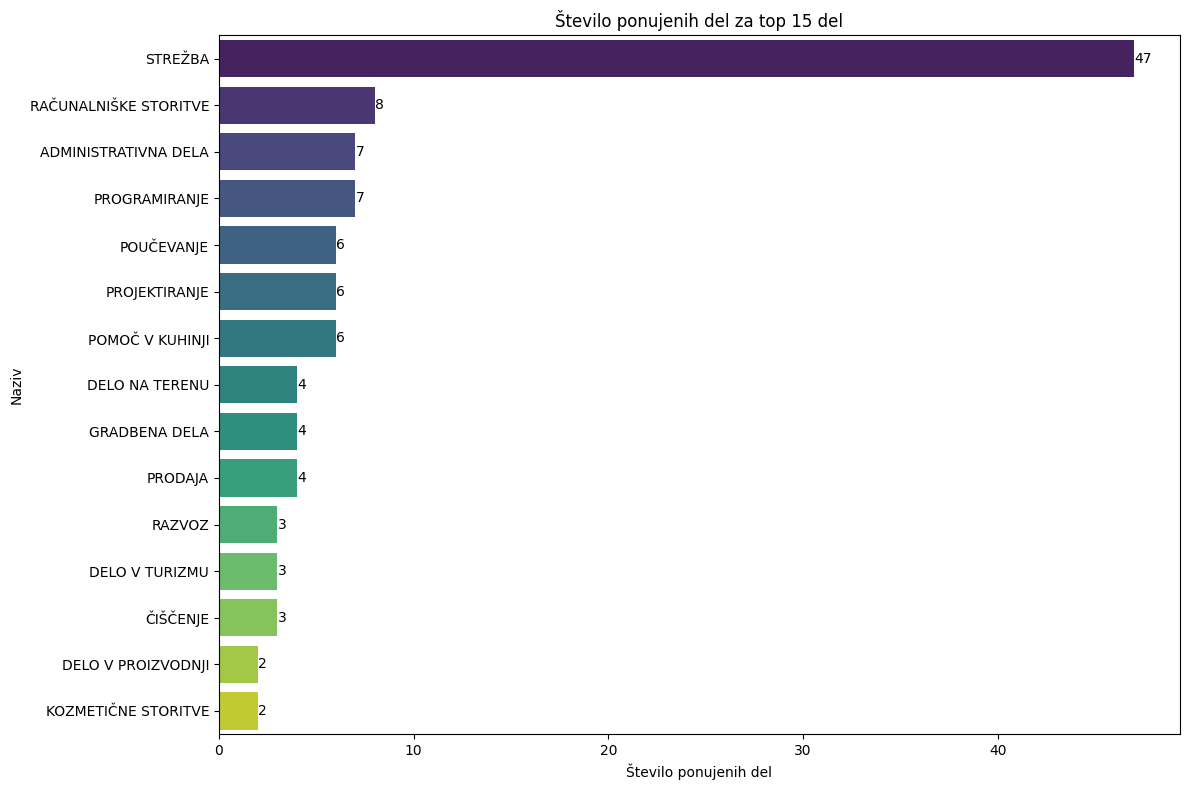

In [34]:
naziv_st = df_ppd_true['naziv'].value_counts().head(15)


naziv_st_df = naziv_st.reset_index()
naziv_st_df.columns = ['naziv', 'pojavitve']

# Ustvari horizontalni diagram
plt.figure(figsize=(12, 8))
sns.barplot(x='pojavitve', y='naziv', data=naziv_st_df, palette='viridis')

# Doda oznake
for indeks, vrsta in naziv_st_df.iterrows():
    plt.text(vrsta['pojavitve'] + 0.02, indeks, f"{vrsta['pojavitve']}", va='center', ha='left', fontsize=10, color='black')

plt.title('Število ponujenih del za top 15 del')
plt.xlabel('Število ponujenih del')
plt.ylabel('Naziv')
plt.tight_layout()
plt.show()

Zgoraj je narisan stolpični horizontalni graf, ki prikazuje število ponujenih del, glede na top 15 del.

Ker je del s plačami po dogovoru procentualno zelo malo, je bilo pričakovano, da bo tudi številke za število del precej nižje.Mi je pa še vseeno presenetljivo, da je veliko del v strežbi plačanih po dogovoru, saj bi pričakovala več del v programiranju s plačo po dogovoru in tudi v poučevanju, čeprav če skupaj združimo programiranje in računalniške storitve pridejo na razumljivo drugo mesto. Dela, ki pa jih tu sploh nisem pričakovala so prodaja, razvoz in delo v proizvodnji. Takšna dela, ki ponavadi niso ravno zelo dobro plačana se zdi čudno, da bi bila plača po dogovoru, saj vsaj meni ta besedna zveza vzbudi občutek višjega plačila.

<ipython-input-35-b66f3f0784c4>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pojavitve', y='lokacija', data=lokacija_st_df, palette='viridis')


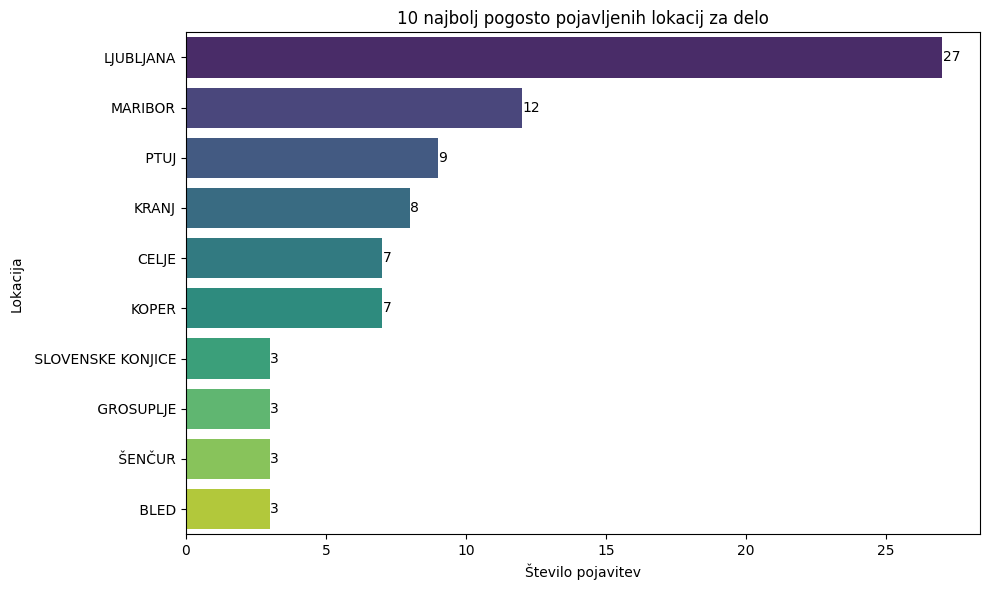

In [35]:
lokacija_st = df_ppd_true['lokacija'].value_counts().head(10)


lokacija_st_df = lokacija_st.reset_index()
lokacija_st_df.columns = ['lokacija', 'pojavitve']

# Ustvari horizontalni diagram
plt.figure(figsize=(10, 6))
sns.barplot(x='pojavitve', y='lokacija', data=lokacija_st_df, palette='viridis')

# Doda oznake
for indeks, vrsta in lokacija_st_df.iterrows():
    plt.text(vrsta['pojavitve'] + 0.02, indeks, f"{vrsta['pojavitve']}", va='center', ha='left', fontsize=10, color='black')

plt.title('10 najbolj pogosto pojavljenih lokacij za delo')
plt.xlabel('Število pojavitev')
plt.ylabel('Lokacija')
plt.tight_layout()
plt.show()

Zgornji horizontalni stolpični graf prikazuje 10 najbolj pogosto pojavljenih lokacij za delo.

Ker so številke tako nizke, sem se tu odločila prikazati 10 lokacij. Verjamem da Ljubljana in Maribor, ki zasedata sam vrh ne presenečata. Mi je pa zanimivo, da je Ptuj tako visoko, in morda bi zaradi višjega stndarda pričakovala, da je Bled višje na lestvici, saj je precej turistično mesto, ki sprejme tik po Ljubljani največ tujih premožnih gostov, čemur tudi sledi višje plačano in cenjeno osebje, torej več del po dogovoru.

<ipython-input-36-8d06334afeba>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pojavitve', y='delovnik', data=delovnik_st_df, palette='viridis')


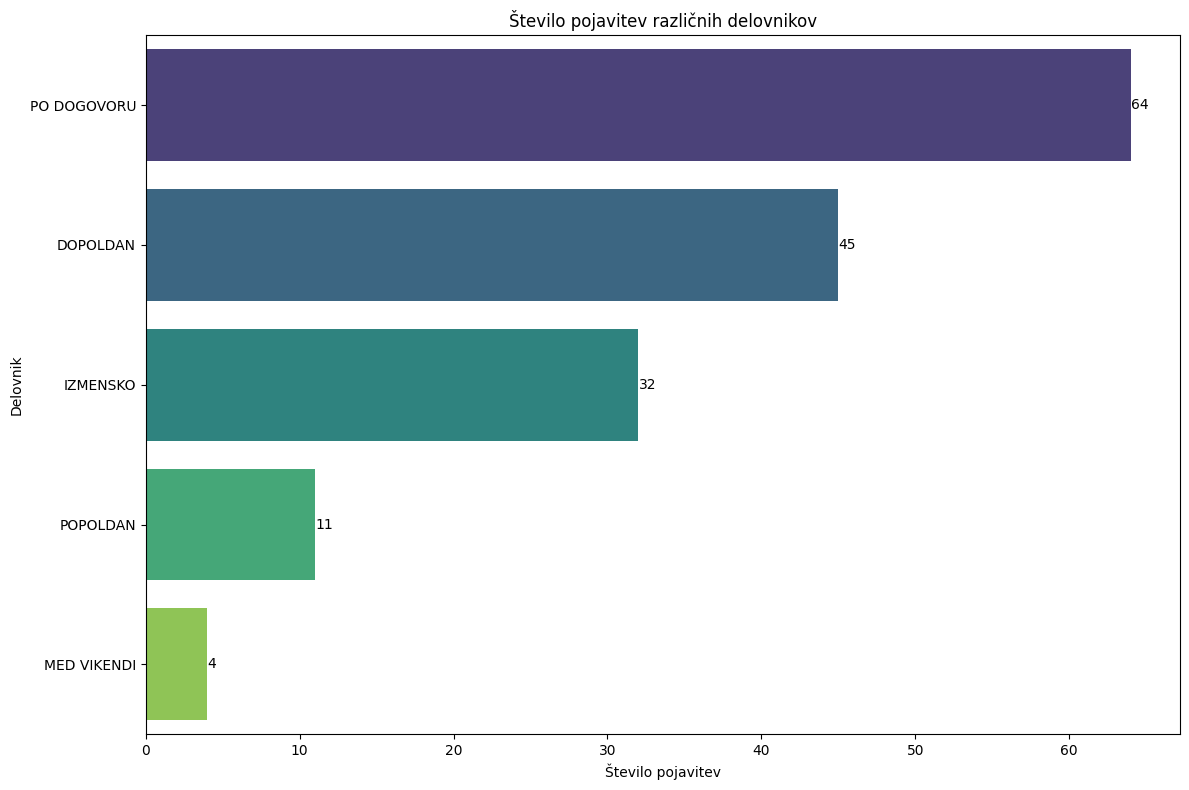

In [36]:
delovnik_st = df_ppd_true['delovnik'].value_counts()


delovnik_st_df = delovnik_st.reset_index()
delovnik_st_df.columns = ['delovnik', 'pojavitve']

# Ustvari horizontalni diagram
plt.figure(figsize=(12, 8))
sns.barplot(x='pojavitve', y='delovnik', data=delovnik_st_df, palette='viridis')

# doda oznake
for indeks, vrsta in delovnik_st_df.iterrows():
    plt.text(vrsta['pojavitve'] + 0.02, indeks, f"{vrsta['pojavitve']}", va='center', ha='left', fontsize=10, color='black')

plt.title('Število pojavitev različnih delovnikov')
plt.xlabel('Število pojavitev')
plt.ylabel('Delovnik')
plt.tight_layout()
plt.show()

Zgoraj je prikazan horizontalni stolpični graf, ki prikazuje število pojavitev različnih delovnikov.

Ponovno bi med deli po dogovoru pričakovala, da je največ takih ki se odvijajo med vikendi, vendar temu očitno ni tako. Me pa tudi ne preseneča, da je največ takih, ki so po dogovoru, saj tudi to lahko pomeni, občasno delo med vikendi. Poleg tega, bi si mislila, da je delo dopoldan, manj prisotno tam, kjer je plača po dogovoru, vendar glede na to katera dela so najbolj iskana pri plači po dogovoru (programiranje, poučevanje, administrativna dela, strežba...) to nekako ne preseneča, ko povežeš podatke med sabo.

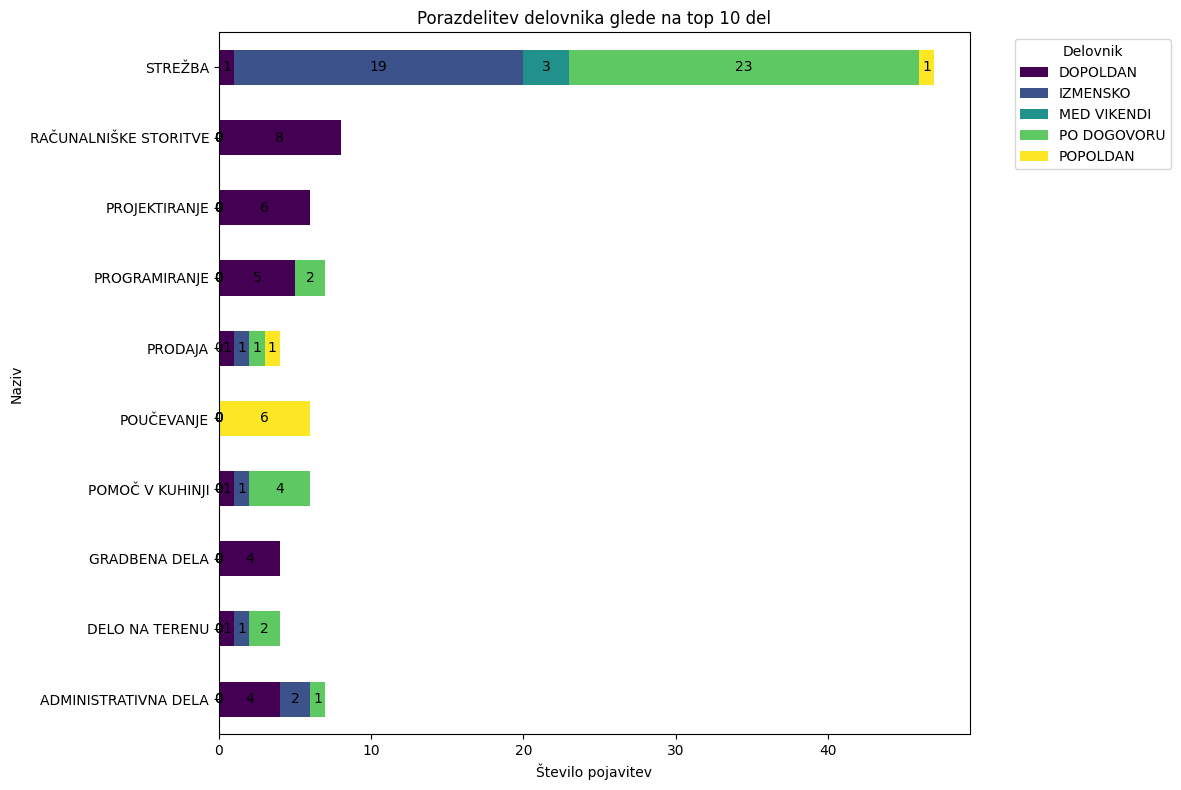

In [37]:
# prešteje število ponovitev za posamezen naziv in določi 10 najpogostejših
top_10_del = df_ppd_true['naziv'].value_counts().head(10).index

#  iz df izberi le dela, ki so v top 10
df_top_10_del = df_ppd_true[df_ppd_true['naziv'].isin(top_10_del)]

# Ustvari pivotno tabelo za število pojavitev različnih delovnih časov, za vsako izmed 10 najbolj pogostih del
pivotna_tabela = df_top_10_del.pivot_table(index='naziv', columns='delovnik', aggfunc='size', fill_value=0)

# Izriši sestavljen horizontalen stolpični diagram
ax = pivotna_tabela.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='viridis')

# Add the frequency numbers next to the bars
for i in ax.containers:
    ax.bar_label(i, label_type='center')

plt.title('Porazdelitev delovnika glede na top 10 del')
plt.xlabel('Število pojavitev')
plt.ylabel('Naziv')
plt.legend(title='Delovnik', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Zgoraj je prikazan horizontalni stolpični diagram, ki prikazuje kakšna je porazdelitev delovnika pri 10 najbolj pogosto ponujenih delih.


Najbolj me preseneča, da je poučevanje samo popoldan, čeprav ne vem za kakšne vrste poučevanja gre, saj če gre za poučevanje instrumentov ali drugih šolskih in obšolskih predmetov in športov bi se zdelo bolj razumljivo, da se v času počitnic to za otroke izvaja dopoldan. Pri ostalih delih, pa se mi zdi, da je dokaj pričakovan nabor delovnikov.

## 4 Statistična analiza

count    3826.00
mean        7.55
std         1.27
min         6.20
25%         6.88
50%         7.30
75%         8.00
max        30.12
Name: placa_neto, dtype: float64
Q1 (25ti percentil): 6.88
Mediana (50ti percentil): 7.3
Q3 (75ti percentil): 8.0
Modus: 6.2


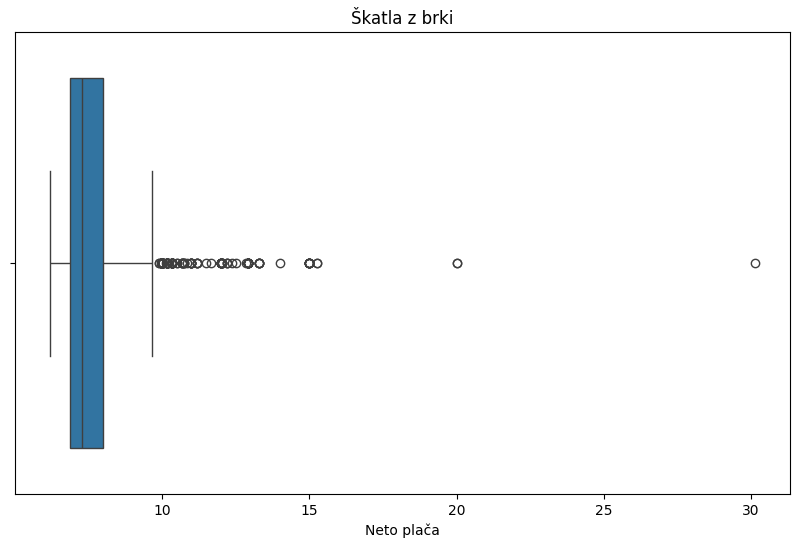

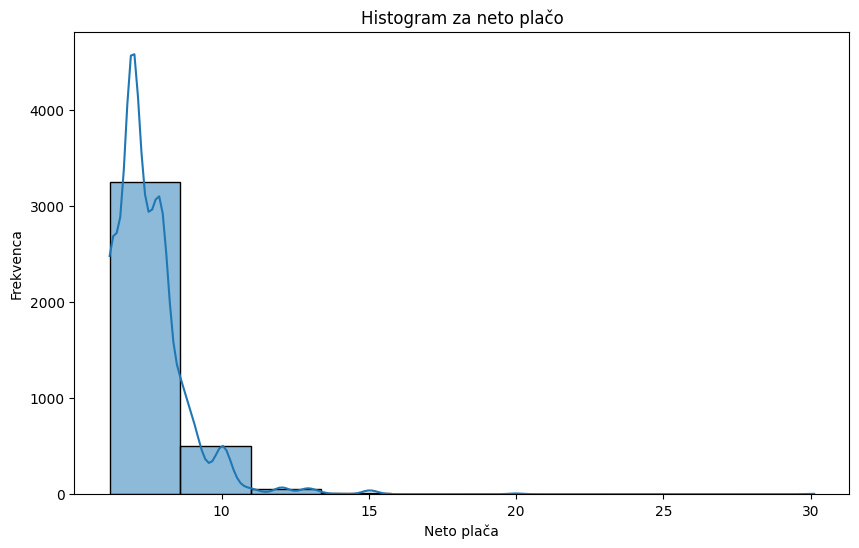

In [40]:
#izračun osnovnih statističnih podatkov in zaokroženih na dve decimalki
statistika = df_ppd_false['placa_neto'].describe().round(2)
#izračun modusa
modus = df_ppd_false['placa_neto'].mode().round(2)[0]

print(statistika)

# izračun kvartilov in mediane
q1 = round(df_ppd_false['placa_neto'].quantile(0.25), 2)
mediana = round(df_ppd_false['placa_neto'].median(), 2)
q3 = round(df_ppd_false['placa_neto'].quantile(0.75), 2)

dodatna_statistika = {
    'Q1 (25ti percentil)': q1,
    'Mediana (50ti percentil)': mediana,
    'Q3 (75ti percentil)': q3,
    'Modus': modus
}


for kljuc, vrednost in dodatna_statistika.items():
    print(f'{kljuc}: {vrednost}')

plt.figure(figsize=(10, 6))
sns.boxplot(x=df_ppd_false['placa_neto'])
plt.title('Škatla z brki')
plt.xlabel('Neto plača')
plt.show()

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_ppd_false['placa_neto'], bins=10, kde=True)
plt.title('Histogram za neto plačo')
plt.xlabel('Neto plača')
plt.ylabel('Frekvenca')
plt.show()


Za konec pa sem pripravila še malce statistične analize za neto plačo na sploh in prišla do naslednjih ugotovitev:

skupna povprečna plača znaša 7.55€, kar se zdi precej veliko. Standardni odklon znaša 1.27€, kar pomeni, da se večino plač giba med 6.28€ in 8.82€, kar se zdi pričakovano, saj je zelo malo plač višjih. Najnižja neto plača je seveda tudi minimalna delovna postavka, kar po novem znaša 6.20€, navišja pa doseže, kar neverjetnih 30.12€. Za boljši prikaz teh podatkov sem izrisala tudi škatlo z brki in histogram, ki prikazuje te podatke. Zanimiv podatek je tudi mediana, ki pove, da je polovica podatkov pod 7.30€ in polovica višjih kot 7.30€. Podatek, ki pa se mi zdi tudi pomemben je dejstvo, da je najbolj pogosta plačilna postavka ravno minimalna, torej 6.20€, kar sicer ni presenetljivo, vendar pa nam še vseeno pove, da je največ del plačanih minimalno.